In [2]:
import pandas as pd
from sqlalchemy import create_engine
from sklearn.model_selection import train_test_split

engine = create_engine('sqlite:///data/creditrisk.db')
df = pd.read_sql('SELECT * FROM model_ready', engine)

X = df.drop(columns='target')
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Bad rate train: {y_train.mean():.2%} | Bad rate test: {y_test.mean():.2%}")

Train: (800, 18), Test: (200, 18)
Bad rate train: 30.00% | Bad rate test: 30.00%


In [3]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

lr = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
lr.fit(X_train_scaled, y_train)

print("Model trained ✅")

Model trained ✅


In [4]:
import numpy as np
from sklearn.metrics import roc_auc_score

y_pred_proba = lr.predict_proba(X_test_scaled)[:, 1]

# AUC & Gini
auc = roc_auc_score(y_test, y_pred_proba)
gini = 2 * auc - 1

# KS Statistic
df_results = pd.DataFrame({'target': y_test, 'proba': y_pred_proba})
df_results = df_results.sort_values('proba', ascending=False)
df_results['cum_bad'] = (df_results['target'] == 1).cumsum() / (y_test == 1).sum()
df_results['cum_good'] = (df_results['target'] == 0).cumsum() / (y_test == 0).sum()
ks = (df_results['cum_bad'] - df_results['cum_good']).abs().max()

print(f"AUC:  {auc:.4f}")
print(f"Gini: {gini:.4f}")
print(f"KS:   {ks:.4f}")

AUC:  0.8255
Gini: 0.6510
KS:   0.6000


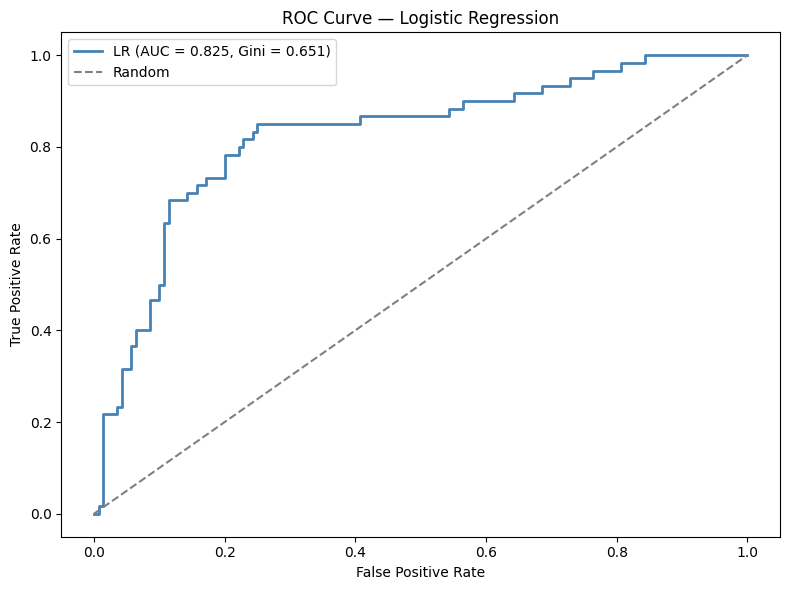

In [5]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve

fpr, tpr, _ = roc_curve(y_test, y_pred_proba)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='steelblue', lw=2, label=f'LR (AUC = {auc:.3f}, Gini = {gini:.3f})')
plt.plot([0, 1], [0, 1], color='grey', linestyle='--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — Logistic Regression')
plt.legend()
plt.tight_layout()
plt.show()

In [6]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1,
    scale_pos_weight=700/300,  # handles class imbalance
    random_state=42,
    eval_metric='auc',
    verbosity=0
)

xgb.fit(X_train, y_train)

# Metrics
y_pred_xgb = xgb.predict_proba(X_test)[:, 1]
auc_xgb = roc_auc_score(y_test, y_pred_xgb)
gini_xgb = 2 * auc_xgb - 1

df_xgb = pd.DataFrame({'target': y_test, 'proba': y_pred_xgb})
df_xgb = df_xgb.sort_values('proba', ascending=False)
df_xgb['cum_bad'] = (df_xgb['target'] == 1).cumsum() / (y_test == 1).sum()
df_xgb['cum_good'] = (df_xgb['target'] == 0).cumsum() / (y_test == 0).sum()
ks_xgb = (df_xgb['cum_bad'] - df_xgb['cum_good']).abs().max()

print("XGBoost Results:")
print(f"AUC:  {auc_xgb:.4f}")
print(f"Gini: {gini_xgb:.4f}")
print(f"KS:   {ks_xgb:.4f}")

print("\nModel Comparison:")
print(f"{'Model':<12} {'AUC':>8} {'Gini':>8} {'KS':>8}")
print(f"{'LR':<12} {auc:.8f} {gini:.8f} {ks:.8f}")
print(f"{'XGBoost':<12} {auc_xgb:.8f} {gini_xgb:.8f} {ks_xgb:.8f}")

XGBoost Results:
AUC:  0.8090
Gini: 0.6181
KS:   0.5286

Model Comparison:
Model             AUC     Gini       KS
LR           0.82547619 0.65095238 0.60000000
XGBoost      0.80904762 0.61809524 0.52857143


In [ ]:
import pickle
artifacts = {
    'lr_model'  : lr,           # your fitted LogisticRegression
    'woe_bins'  : woe_bins,     # dict: {feature: df with 'bin' & 'woe' cols}
    'X_train'   : X_train_woe,  # WoE-encoded train features
    'X_test'    : X_test_woe,   # WoE-encoded test features
    'y_train'   : y_train,
    'y_test'    : y_test,
}
with open('model_artifacts.pkl', 'wb') as f:
    pickle.dump(artifacts, f)
print("Saved ✅")

In [8]:
%whos

Variable             Type                  Data/Info
----------------------------------------------------
LogisticRegression   type                  <class 'sklearn.linear_mo<...>stic.LogisticRegression'>
StandardScaler       type                  <class 'sklearn.preproces<...>ng._data.StandardScaler'>
X                    DataFrame             Shape: (1000, 18)
XGBClassifier        type                  <class 'xgboost.sklearn.XGBClassifier'>
X_test               DataFrame             Shape: (200, 18)
X_test_scaled        ndarray               200x18: 3600 elems, type `float64`, 28800 bytes
X_train              DataFrame             Shape: (800, 18)
X_train_scaled       ndarray               800x18: 14400 elems, type `float64`, 115200 bytes (112.5 kb)
auc                  float                 0.8254761904761905
auc_xgb              float                 0.809047619047619
create_engine        function              <function create_engine at 0x15a357ba0>
df                   DataFrame 

In [9]:
import pickle

artifacts = {
    'lr_model'      : lr,
    'X_train_scaled': X_train_scaled,
    'X_test_scaled' : X_test_scaled,
    'X_train'       : X_train,
    'X_test'        : X_test,
    'y_train'       : y_train,
    'y_test'        : y_test,
}

with open('model_artifacts.pkl', 'wb') as f:
    pickle.dump(artifacts, f)

print("Artifacts saved ✅")

Artifacts saved ✅
